<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT Ocean Model Intercomparison Project : EORCA12-ERA5v1 Test Case</h1>
    <p style="margin: 10;"></p>
</div>



## 📦**Imports** 

In [1]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box

CPU times: user 4.05 s, sys: 560 ms, total: 4.61 s
Wall time: 4.93 s


## 🧮 **Required variables**

In [5]:
reg="AG"
season="JAS"
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!
endpoint_url =  "https://minio.dive.edito.eu/"




## 🔍 **Check the S3 Endpoint**  

In [6]:
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!
endpoint_url =  "https://minio.dive.edito.eu/"
fs = s3fs.S3FileSystem(anon=True,endpoint_url=endpoint_url)
# List contents of the bucket
bucket_name = 's3://project-moi-swot-omip/GLO36V1'
contents = fs.ls(bucket_name)
print("Bucket contents:")
for item in contents:
    print(item)

Bucket contents:
project-moi-swot-omip/GLO36V1/cycle_.keep
project-moi-swot-omip/GLO36V1/cycle_008
project-moi-swot-omip/GLO36V1/cycle_009
project-moi-swot-omip/GLO36V1/cycle_010
project-moi-swot-omip/GLO36V1/cycle_011
project-moi-swot-omip/GLO36V1/cycle_012
project-moi-swot-omip/GLO36V1/cycle_013
project-moi-swot-omip/GLO36V1/cycle_014
project-moi-swot-omip/GLO36V1/cycle_015
project-moi-swot-omip/GLO36V1/cycle_016
project-moi-swot-omip/GLO36V1/cycle_017
project-moi-swot-omip/GLO36V1/cycle_018
project-moi-swot-omip/GLO36V1/cycle_019
project-moi-swot-omip/GLO36V1/cycle_020
project-moi-swot-omip/GLO36V1/cycle_021
project-moi-swot-omip/GLO36V1/cycle_022
project-moi-swot-omip/GLO36V1/cycle_023
project-moi-swot-omip/GLO36V1/cycle_024
project-moi-swot-omip/GLO36V1/cycle_025
project-moi-swot-omip/GLO36V1/cycle_026


## 📊 **Load datasets and compute Wavenumber spectra**

In [7]:
if reg=="GS":
    roi = {
        "lon_min": -60,
        "lon_max": -50,
        "lat_min": 30,
        "lat_max": 40
    }
    pos_reg=[-85, -30, 15, 55]
elif reg=="AG":
    roi = {
        "lon_min": 20,
        "lon_max": 40,
        "lat_min": -40,
        "lat_max": -20
    }
    pos_reg=[0, 60, -55, -25]

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

selected = []

for feature in data["features"]:
    poly = shape(feature["geometry"])
    if poly.intersects(roi_poly):
        selected.append(poly)

In [8]:
selected



[<POLYGON ((10 -50, 20 -50, 20 -40, 10 -40, 10 -50))>,
 <POLYGON ((20 -50, 30 -50, 30 -40, 20 -40, 20 -50))>,
 <POLYGON ((30 -50, 40 -50, 40 -40, 30 -40, 30 -50))>,
 <POLYGON ((40 -50, 50 -50, 50 -40, 40 -40, 40 -50))>,
 <POLYGON ((10 -40, 20 -40, 20 -30, 10 -30, 10 -40))>,
 <POLYGON ((30 -40, 40 -40, 40 -30, 30 -30, 30 -40))>,
 <POLYGON ((40 -40, 50 -40, 50 -30, 40 -30, 40 -40))>]

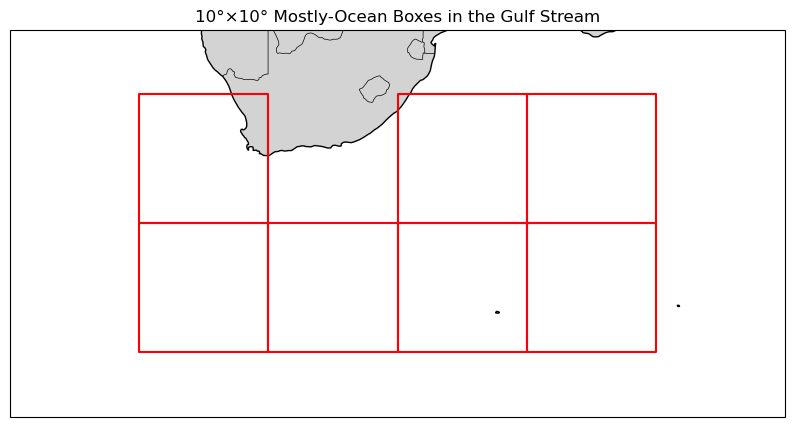

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent to Gulf Stream region
ax.set_extent(pos_reg, crs=ccrs.PlateCarree())

# Add base map
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Plot selected boxes
for poly in selected:
    ax.add_geometries(
        [poly],
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="red",
        linewidth=1.5
    )

ax.set_title("10°×10° Mostly-Ocean Boxes in the Gulf Stream")
plt.show()

## 🔄 **Identify the cycle numbers within the specified time range** 

In [6]:
if season=="JFM":    
    start_date = "01012024" # "DDMMYYYY"
    end_date ="31032024"
elif season=="JAS":
    start_date = "01072024" # "DDMMYYYY"
    end_date ="30092024"

if season =="JFM":
    file_path = "https://minio.lab.dive.edito.eu/project-meom-ige/cycles_periods.csv" # works only for winter period
elif season =="JAS":
    file_path = "time_ranges.csv"  # for summer

matching_cycles = dp.get_matching_cycles(file_path, start_date, end_date)

def formater_numeros_concis(liste_numeros):
  return [str(numero).zfill(3) for numero in liste_numeros]
    
matching_cycles = formater_numeros_concis(matching_cycles)
matching_cycles

['017', '018', '019', '020', '021']

In [7]:
%%time
import save_spect_json2 as ssj
bx=0
for poly in selected[:4]:
    #lon_min, lat_min, lon_max, lat_max
    area = list(poly.bounds)
    if reg=="GS":
        area[0]=360+area[0]
        area[2]=360+area[2]
    elif reg=="AG":
        area[0]=area[0]
        area[2]=area[2]
    area = tuple(area)
    #print(area)
    datasets_dict = dp.read_swot_ncfiles_S3subfolders(
        s3_folder,
        matching_cycles,
        endpoint_url,
        area)
    
    has_converged, filled_datasets = dp.fill_nan(datasets_dict, varname = "ssh")

    segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")

    psd_dict, freqs_dict = sp.calculate_psd(segments_dict)
    # Calculate PSD Mean
    psd_mean, freqs_mean = sp.psd_mean_and_freq(psd_dict,freqs_dict)

    ssj.save_spect(("GS_box_"+str(bx)),"GLORYS36",season,freqs_mean,psd_mean,area[0],area[2],area[1],area[3],start_date,end_date)
    bx=bx+1
# It will be more faster if we load all the data and after select area
# I should save for every region or just one file

17_020_ included.
17_145_ included.
17_173_ included.
17_186_ included.
17_201_ included.
17_229_ included.
17_242_ included.
17_257_ included.
17_270_ included.
17_298_ included.
17_326_ included.
17_423_ included.
17_451_ included.
17_479_ included.
17_492_ included.
17_507_ included.
17_520_ included.
17_535_ included.
17_548_ included.
17_563_ included.
17_576_ included.
18_020_ included.
18_145_ included.
18_173_ included.
18_186_ included.
18_201_ included.
18_214_ included.
18_229_ included.
18_242_ included.
18_257_ included.
18_270_ included.
18_298_ included.
18_326_ included.
18_423_ included.
18_451_ included.
18_479_ included.
18_492_ included.
18_507_ included.
18_520_ included.
18_535_ included.
18_548_ included.
18_563_ included.
18_576_ included.
19_020_ included.
19_145_ included.
19_173_ included.
19_186_ included.
19_201_ included.
19_214_ included.
19_229_ included.
19_242_ included.
19_257_ included.
19_270_ included.
19_298_ included.
19_326_ included.
19_423_ in

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


JSON file created
17_033_ included.
17_061_ included.
17_074_ included.
17_089_ included.
17_102_ included.
17_117_ included.
17_130_ included.
17_145_ included.
17_158_ included.
17_186_ included.
17_311_ included.
17_339_ included.
17_367_ included.
17_380_ included.
17_395_ included.
17_408_ included.
17_423_ included.
17_436_ included.
17_451_ included.
17_464_ included.
17_492_ included.
18_033_ included.
18_061_ included.
18_074_ included.
18_089_ included.
18_102_ included.
18_117_ included.
18_130_ included.
18_145_ included.
18_158_ included.
18_186_ included.
18_214_ included.
18_311_ included.
18_339_ included.
18_367_ included.
18_380_ included.
18_395_ included.
18_408_ included.
18_423_ included.
18_436_ included.
18_451_ included.
18_464_ included.
18_492_ included.
19_033_ included.
19_061_ included.
19_074_ included.
19_089_ included.
19_102_ included.
19_117_ included.
19_130_ included.
19_145_ included.
19_158_ included.
19_186_ included.
19_214_ included.
19_311_ in

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


JSON file created
17_005_ included.
17_018_ included.
17_033_ included.
17_046_ included.
17_074_ included.
17_102_ included.
17_199_ included.
17_227_ included.
17_255_ included.
17_268_ included.
17_283_ included.
17_296_ included.
17_311_ included.
17_324_ included.
17_339_ included.
17_352_ included.
17_380_ included.
17_505_ included.
17_533_ included.
17_546_ included.
17_561_ included.
17_574_ included.
18_005_ included.
18_018_ included.
18_033_ included.
18_046_ included.
18_074_ included.
18_102_ included.
18_199_ included.
18_227_ included.
18_255_ included.
18_268_ included.
18_283_ included.
18_296_ included.
18_311_ included.
18_324_ included.
18_339_ included.
18_352_ included.
18_380_ included.
18_505_ included.
18_533_ included.
18_546_ included.
18_561_ included.
18_574_ included.
19_005_ included.
19_018_ included.
19_033_ included.
19_046_ included.
19_074_ included.
19_102_ included.
19_199_ included.
19_227_ included.
19_255_ included.
19_268_ included.
19_283_ in

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


JSON file created
17_007_ included.
17_158_ included.
17_173_ included.
17_186_ included.
17_201_ included.
17_229_ included.
17_242_ included.
17_257_ included.
17_270_ included.
17_285_ included.
17_298_ included.
17_451_ included.
17_464_ included.
17_479_ included.
17_492_ included.
17_507_ included.
17_520_ included.
17_535_ included.
17_548_ included.
17_563_ included.
17_576_ included.
18_007_ included.
18_158_ included.
18_173_ included.
18_186_ included.
18_201_ included.
18_214_ included.
18_229_ included.
18_242_ included.
18_257_ included.
18_270_ included.
18_285_ included.
18_298_ included.
18_451_ included.
18_464_ included.
18_479_ included.
18_492_ included.
18_507_ included.
18_520_ included.
18_535_ included.
18_548_ included.
18_563_ included.
18_576_ included.
19_007_ included.
19_158_ included.
19_173_ included.
19_186_ included.
19_201_ included.
19_214_ included.
19_229_ included.
19_242_ included.
19_257_ included.
19_270_ included.
19_285_ included.
19_298_ in

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


JSON file created
CPU times: user 29min 58s, sys: 19min 55s, total: 49min 54s
Wall time: 5h 53min 33s


## 💾 **Save Results and Information in JSON File**

## 📤 **Export Results to the S3 Endpoint** 

In [13]:
fs = s3fs.S3FileSystem( anon=True, endpoint_url="https://minio.lab.dive.edito.eu", use_ssl=False ) 

In [14]:
json_file = str(nom_region)+"_"+str(name_season)+"_"+str(model)+".json"
fs.put(json_file, "project-meom-ige/OMIP/")

[None]

In [16]:
fs